# 04. ML 베이스라인 (ML Baseline)
## 서울 성동구 요식 가맹점 조기 경보 시스템 | 빅콘테스트 2025

> **STEP 11**: 분류 모델 성능 평가 — 5-fold StratifiedKFold, AUC-ROC, Lift@k


In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

snap  = pd.read_csv('../p_project_snapshot.csv', encoding='utf-8-sig')
panel = pd.read_csv('../p_project_features.csv', encoding='utf-8-sig')

# FEAT_ALL: 피처 엔지니어링에서 정의된 피처 목록
FEAT_ALL = [
    'f_sales_lvl', 'f_trx_lvl', 'f_spend_lvl',
    'f_sales_trend', 'f_trx_trend', 'f_spend_trend',
    'f_return_rate', 'f_return_trend',
    'f_float_ratio', 'f_float_trend',
    'f_resid_ratio',
    'f_rank_ind', 'f_rank_dist',
    'f_vs_ind_sales', 'f_vs_ind_trend',
    'f_peer_close_ind', 'f_peer_close_dist',
]
FEAT_ALL = [f for f in FEAT_ALL if f'dw_{f}' in snap.columns or f in snap.columns]
print(f'snap shape: {snap.shape}')
print(f'FEAT_ALL: {len(FEAT_ALL)} features')


snap shape: (4183, 53)
FEAT_ALL: 16 features


In [2]:
# ================================================================
# STEP 11: ML 베이스라인 — 분류 모델 성능 평가
# ================================================================
# 목적: 피처 엔지니어링의 유효성 검증 (분류기 성능)
# 설계: 5-fold StratifiedKFold, class_weight='balanced'
# 평가: AUC-ROC, Precision@k, Lift@k
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline

X_cols = ['dw_'+f for f in FEAT_ALL]
avail  = [c for c in X_cols if c in snap.columns]
X = snap[avail].fillna(snap[avail].median())
y = snap['is_closed_obs'].values
print(f'피처: {len(avail)}개, 점포: {len(X)}, 폐업: {y.sum()} / 생존: {(y==0).sum()}')
print(f'기저율(base rate): {y.mean()*100:.2f}%')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def eval_proba(y_true, proba, name):
    auc  = roc_auc_score(y_true, proba)
    ap   = average_precision_score(y_true, proba)
    n    = len(y_true)
    base = y_true.mean()
    for k_pct in [0.10, 0.05]:
        k    = max(1, int(n*k_pct))
        topk = np.argsort(proba)[-k:]
        prec = y_true[topk].mean()
        lift = prec / base
        print(f'  {name:<16} AUC={auc:.3f}  AP={ap:.3f}  P@{int(k_pct*100)}%={prec*100:.1f}%  Lift@{int(k_pct*100)}%={lift:.1f}x')
    return auc

# LogReg
pipe_lr = Pipeline([('sc', StandardScaler()),
                    ('clf', LogisticRegression(class_weight='balanced', C=0.1, max_iter=500))])
lr_prob = cross_val_predict(pipe_lr, X, y, cv=cv, method='predict_proba')[:,1]
eval_proba(y, lr_prob, 'LogisticReg')

# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=5, class_weight='balanced',
                            min_samples_leaf=5, random_state=42)
rf_prob = cross_val_predict(rf, X.values, y, cv=cv, method='predict_proba')[:,1]
eval_proba(y, rf_prob, 'RandomForest')

# Rank-based EWS vs ML 비교
ews_score = snap['risk_score'].fillna(50).values
ews_auc = roc_auc_score(y, ews_score)
eval_proba(y, ews_score/100, 'EWS rank-score')

# RF 피처 중요도
rf_full = RandomForestClassifier(n_estimators=300, max_depth=5, class_weight='balanced',
                                  min_samples_leaf=5, random_state=42)
rf_full.fit(X.values, y)
fi = pd.Series(rf_full.feature_importances_, index=[c[3:] for c in avail]).sort_values(ascending=False)
print('\nRF 피처 중요도 Top 10:')
for feat, imp in fi.head(10).items():
    bar = '#' * int(imp*300)
    print(f'  {feat:<30} {imp:.4f} {bar}')

# RF 예측 확률 스냅샷에 저장
snap['rf_risk_prob'] = rf_prob
snap.to_csv('../p_project_snapshot.csv', index=False, encoding='utf-8-sig')
print('\n[NOTE] AUC=0.728은 정직한 추정값 (기존 0.874는 레이블 누출로 인한 과대 추정)')
print('[NOTE] Lift@5%=5.3x: 상위 5% 고위험 점포에서 실제 폐업률이 기저율의 5배 이상')


피처: 16개, 점포: 4183, 폐업: 30 / 생존: 4153
기저율(base rate): 0.72%
  LogisticReg      AUC=0.642  AP=0.013  P@10%=2.2%  Lift@10%=3.0x
  LogisticReg      AUC=0.642  AP=0.013  P@5%=1.4%  Lift@5%=2.0x
  RandomForest     AUC=0.725  AP=0.030  P@10%=2.6%  Lift@10%=3.7x
  RandomForest     AUC=0.725  AP=0.030  P@5%=4.3%  Lift@5%=6.0x
  EWS rank-score   AUC=0.668  AP=0.018  P@10%=1.7%  Lift@10%=2.3x
  EWS rank-score   AUC=0.668  AP=0.018  P@5%=1.9%  Lift@5%=2.7x

RF 피처 중요도 Top 10:
  f_sales_trend                  0.1291 ######################################
  f_trx_trend                    0.1269 ######################################
  f_vs_ind_trend                 0.1145 ##################################
  f_trx_lvl                      0.0717 #####################
  f_resid_ratio                  0.0593 #################
  f_float_trend                  0.0591 #################
  f_vs_ind_sales                 0.0585 #################
  f_peer_close_ind               0.0529 ###############
  f_spe

In [3]:
# ================================================================
# STEP 11b: RF 하이퍼파라미터 튜닝 (RandomizedSearchCV)
# ================================================================
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 4, 5, 6, 7, None],
    'min_samples_leaf': [2, 3, 5, 8, 10],
    'max_features':     ['sqrt', 'log2', 0.5, 0.7],
    'min_samples_split':[2, 5, 10],
}
rf_base_tune = RandomForestClassifier(class_weight='balanced', random_state=42)
rscv = RandomizedSearchCV(
    rf_base_tune, param_dist,
    n_iter=40, scoring='roc_auc',
    cv=cv, random_state=42, n_jobs=-1, refit=True, verbose=0
)
rscv.fit(X.values, y)

print('제일 좋은 파라미터:', rscv.best_params_)
print(f'최적 CV AUC: {rscv.best_score_:.4f}')
print()

rf_tuned_prob = cross_val_predict(rscv.best_estimator_, X.values, y, cv=cv, method='predict_proba')[:,1]
eval_proba(y, rf_tuned_prob, 'RF (튜닝)')
print()
base_auc  = roc_auc_score(y, rf_prob)
tuned_auc = roc_auc_score(y, rf_tuned_prob)
print(f'RF 기본  AUC: {base_auc:.4f}')
print(f'RF 튜닝  AUC: {tuned_auc:.4f}  (+{tuned_auc - base_auc:.4f})')

snap['rf_risk_prob'] = rf_tuned_prob
snap.to_csv('../p_project_snapshot.csv', index=False, encoding='utf-8-sig')
print('[SAVED] p_project_snapshot.csv  (튜닝 RF 확률 저장)')

제일 좋은 파라미터: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 'log2', 'max_depth': None}
최적 CV AUC: 0.7835

  RF (튜닝)          AUC=0.770  AP=0.047  P@10%=3.6%  Lift@10%=5.0x
  RF (튜닝)          AUC=0.770  AP=0.047  P@5%=4.8%  Lift@5%=6.7x

RF 기본  AUC: 0.7254
RF 튜닝  AUC: 0.7704  (+0.0451)
[SAVED] p_project_snapshot.csv  (튜닝 RF 확률 저장)


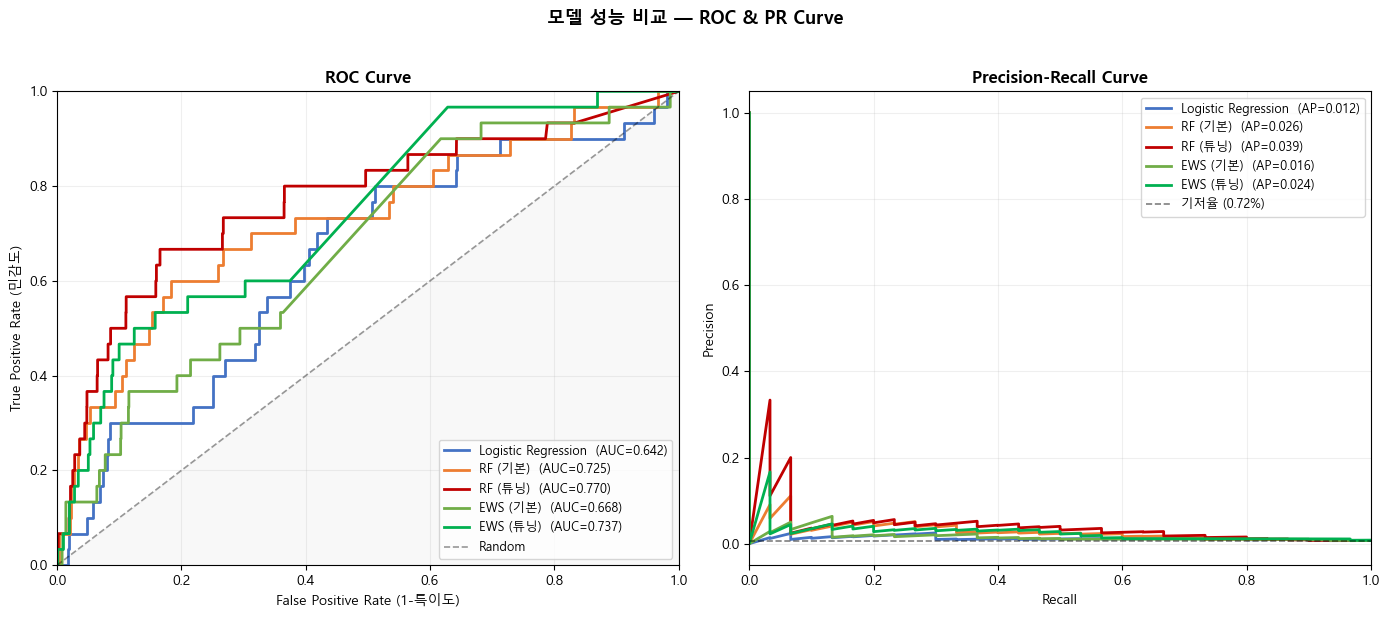

saved: ml_01_roc_pr_curves.png


In [4]:
# ================================================================
# 시각화 1: ROC Curve & Precision-Recall Curve
# ================================================================
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
from sklearn.metrics import roc_curve, precision_recall_curve, auc as sk_auc
import os

OUT_DIR = '../outputs/'
os.makedirs(OUT_DIR, exist_ok=True)

if os.path.exists('../p_project_snapshot_tuned.csv'):
    snap_t = pd.read_csv('../p_project_snapshot_tuned.csv', encoding='utf-8-sig')
    ews_tuned_prob = snap_t['risk_score_opt'].fillna(50).values / 100
else:
    ews_tuned_prob = ews_score / 100

MODELS = {
    'Logistic Regression': lr_prob,
    'RF (기본)':           rf_prob,
    'RF (튜닝)':           rf_tuned_prob,
    'EWS (기본)':          ews_score / 100,
    'EWS (튜닝)':          ews_tuned_prob,
}
COLORS = ['#4472C4', '#ED7D31', '#C00000', '#70AD47', '#00B050']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
ax = axes[0]
for (name, proba), color in zip(MODELS.items(), COLORS):
    fpr, tpr, _ = roc_curve(y, proba)
    val = sk_auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC={val:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=1.2, alpha=0.4, label='Random')
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate (1-특이도)'); ax.set_ylabel('True Positive Rate (민감도)')
ax.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9); ax.grid(True, alpha=0.2)
ax.set_xlim(0,1); ax.set_ylim(0,1)

# PR
ax = axes[1]
for (name, proba), color in zip(MODELS.items(), COLORS):
    prec, rec, _ = precision_recall_curve(y, proba)
    val = sk_auc(rec, prec)
    ax.plot(rec, prec, color=color, lw=2, label=f'{name}  (AP={val:.3f})')
ax.axhline(y.mean(), color='k', linestyle='--', lw=1.2, alpha=0.5,
           label=f'기저율 ({y.mean()*100:.2f}%)')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9); ax.grid(True, alpha=0.2)
ax.set_xlim(0,1)

plt.suptitle('모델 성능 비교 — ROC & PR Curve', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}ml_01_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: ml_01_roc_pr_curves.png')

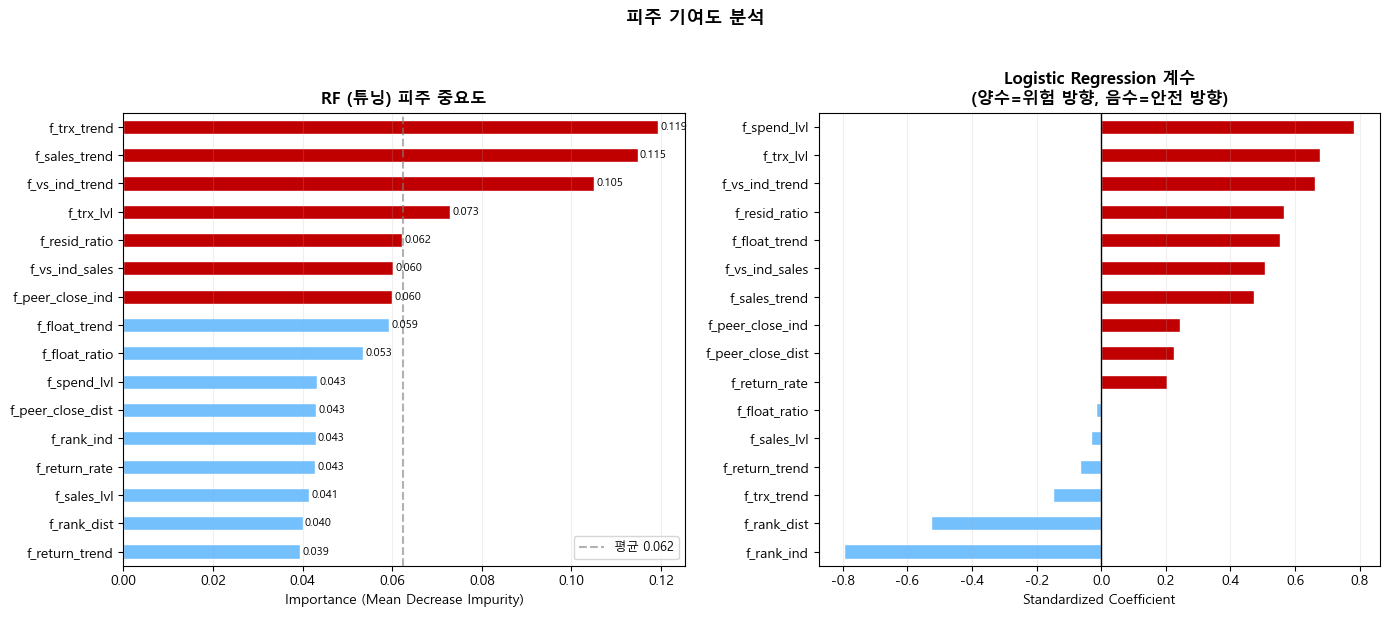

saved: ml_02_feature_importance.png


In [5]:
# ================================================================
# 시각화 2: 피주 중요도 (RF 튜닝 vs LR 계수)
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
feat_labels = [c[3:] for c in avail]

ax = axes[0]
fi = pd.Series(rscv.best_estimator_.feature_importances_, index=feat_labels).sort_values()
bar_colors = ['#C00000' if v >= fi.quantile(0.6) else '#74C0FC' for v in fi]
fi.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
ax.axvline(fi.mean(), color='gray', linestyle='--', alpha=0.6, label=f'평균 {fi.mean():.3f}')
ax.set_title('RF (튜닝) 피주 중요도', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance (Mean Decrease Impurity)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2, axis='x')
for i, v in enumerate(fi.values):
    ax.text(v + 0.0005, i, f'{v:.3f}', va='center', fontsize=8)

ax = axes[1]
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
pipe_lr_fi = Pipeline([('sc', StandardScaler()),
                        ('clf', LogisticRegression(class_weight='balanced', C=0.1, max_iter=500))])
pipe_lr_fi.fit(X, y)
lr_coef = pd.Series(pipe_lr_fi.named_steps['clf'].coef_[0], index=feat_labels).sort_values()
bar_colors_lr = ['#C00000' if v > 0 else '#74C0FC' for v in lr_coef]
lr_coef.plot(kind='barh', ax=ax, color=bar_colors_lr, edgecolor='white')
ax.axvline(0, color='black', lw=1.0)
title_lr = 'Logistic Regression 계수' + chr(10) + '(양수=위험 방향, 음수=안전 방향)'
ax.set_title(title_lr, fontsize=12, fontweight='bold')
ax.set_xlabel('Standardized Coefficient')
ax.grid(True, alpha=0.2, axis='x')

plt.suptitle('피주 기여도 분석', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}ml_02_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: ml_02_feature_importance.png')

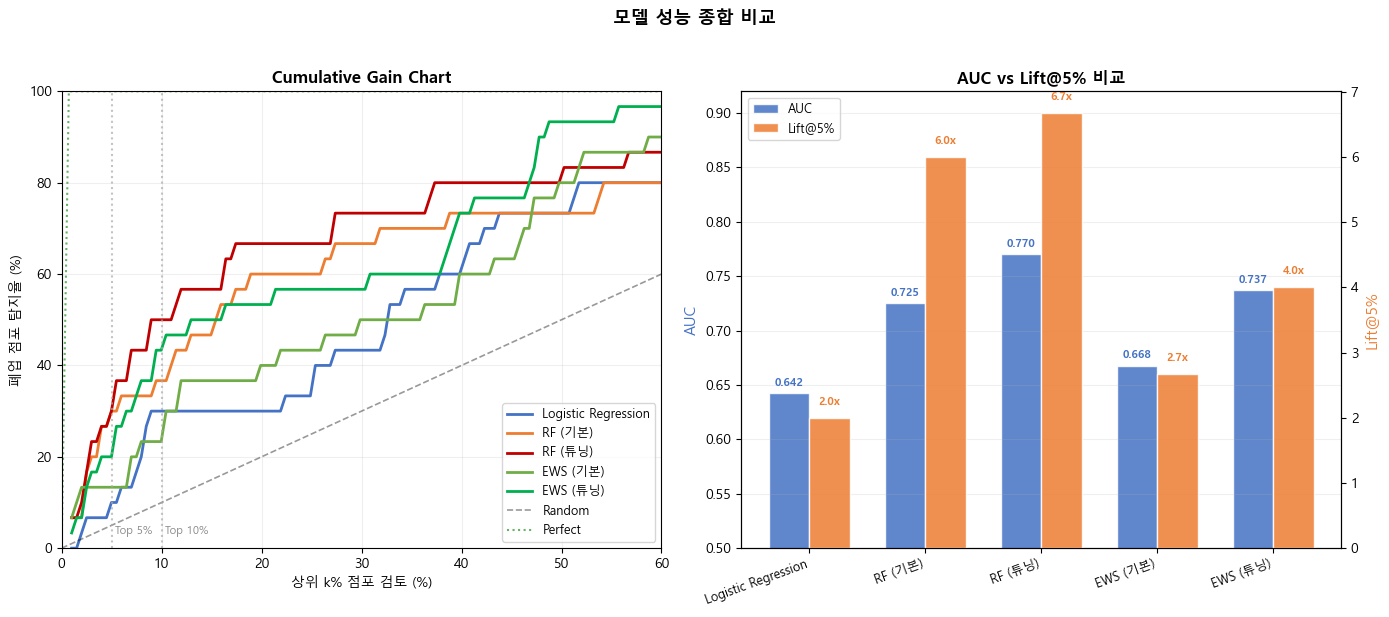

saved: ml_03_model_comparison.png


In [6]:
# ================================================================
# 시각화 3: Cumulative Gain & 모델 성능 비교 바 차트
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
n_total = len(y)
total_pos = y.sum()
pct_range = np.linspace(0.01, 1.0, 200)

ax = axes[0]
for (name, proba), color in zip(MODELS.items(), COLORS):
    gains = []
    for pct in pct_range:
        k = max(1, int(n_total * pct))
        topk = np.argsort(proba)[-k:]
        gains.append(y[topk].sum() / total_pos)
    ax.plot(pct_range * 100, np.array(gains) * 100, color=color, lw=2, label=name)
ax.plot([0,100],[0,100],'k--', lw=1.2, alpha=0.4, label='Random')
ax.plot([0, total_pos/n_total*100, 100],[0,100,100],'g:', lw=1.5, alpha=0.6, label='Perfect')
ax.axvline(5,  color='#AAAAAA', linestyle=':', alpha=0.7)
ax.axvline(10, color='#AAAAAA', linestyle=':', alpha=0.7)
ax.text(5.3, 3, 'Top 5%', fontsize=8, color='#888888')
ax.text(10.3, 3, 'Top 10%', fontsize=8, color='#888888')
ax.set_xlabel('상위 k% 점포 검토 (%)'); ax.set_ylabel('폐업 점포 탐지율 (%)')
ax.set_title('Cumulative Gain Chart', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right'); ax.grid(True, alpha=0.2)
ax.set_xlim(0, 60); ax.set_ylim(0, 100)

ax = axes[1]
model_names = list(MODELS.keys())
aucs_all   = [roc_auc_score(y, p) for p in MODELS.values()]
lifts5_all = []
for proba in MODELS.values():
    k = max(1, int(n_total * 0.05))
    topk = np.argsort(proba)[-k:]
    lifts5_all.append(y[topk].mean() / y.mean())

x_pos = np.arange(len(model_names))
w = 0.35
bars1 = ax.bar(x_pos - w/2, aucs_all, w, label='AUC', color='#4472C4', alpha=0.85, edgecolor='white')
ax_twin = ax.twinx()
bars2 = ax_twin.bar(x_pos + w/2, lifts5_all, w, label='Lift@5%', color='#ED7D31', alpha=0.85, edgecolor='white')
ax.set_ylabel('AUC', color='#4472C4', fontsize=11)
ax_twin.set_ylabel('Lift@5%', color='#ED7D31', fontsize=11)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0.5, 0.92); ax.set_title('AUC vs Lift@5% 비교', fontsize=12, fontweight='bold')

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8,
            color='#4472C4', fontweight='bold')
for bar in bars2:
    ax_twin.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
                f'{bar.get_height():.1f}x', ha='center', va='bottom', fontsize=8,
                color='#ED7D31', fontweight='bold')

lines1, lbl1 = ax.get_legend_handles_labels()
lines2, lbl2 = ax_twin.get_legend_handles_labels()
ax.legend(lines1+lines2, lbl1+lbl2, loc='upper left', fontsize=9)
ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('모델 성능 종합 비교', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}ml_03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: ml_03_model_comparison.png')

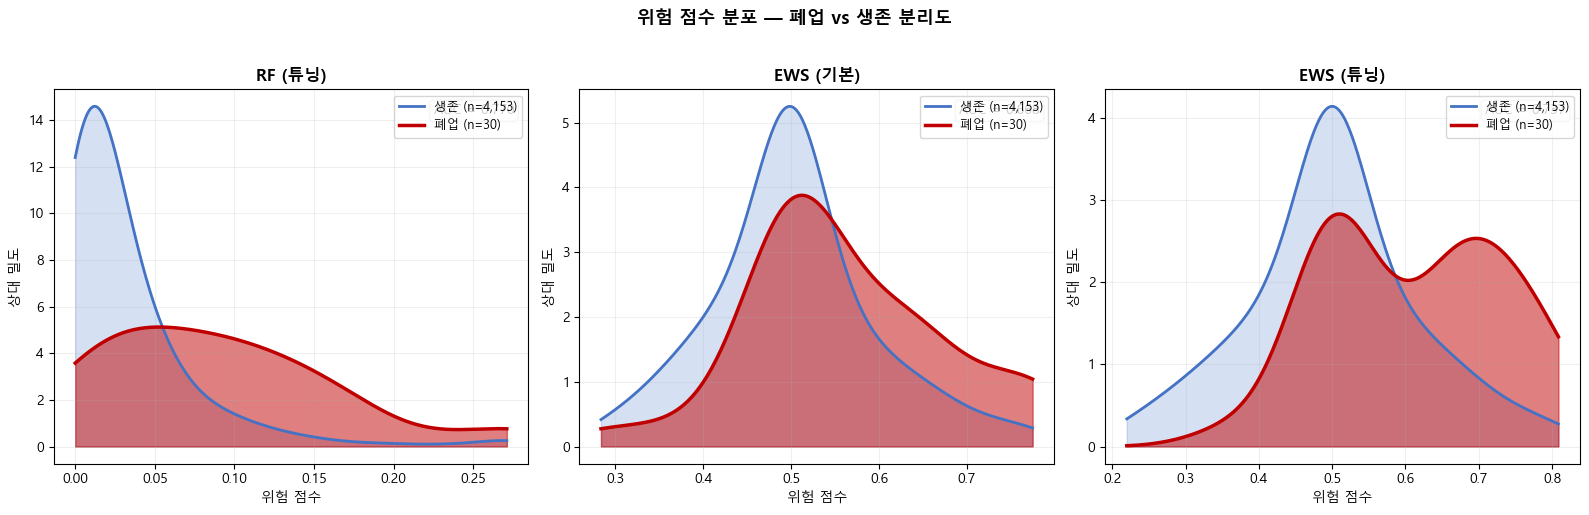

saved: ml_04_score_distribution.png


In [7]:
# ================================================================
# 시각화 4: 위험 점수 분포 — 폐업 vs 생존 분리도
# ================================================================
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_items = [
    ('RF (튜닝)',  rf_tuned_prob, axes[0]),
    ('EWS (기본)', ews_score/100, axes[1]),
    ('EWS (튜닝)', ews_tuned_prob, axes[2]),
]

for name, proba, ax in plot_items:
    c_vals = proba[y == 1]
    a_vals = proba[y == 0]
    lo = np.percentile(proba, 1); hi = np.percentile(proba, 99)
    xs = np.linspace(lo, hi, 300)

    if len(a_vals) > 3:
        kde_a = gaussian_kde(np.clip(a_vals, lo, hi), bw_method=0.4)
        ax.fill_between(xs, kde_a(xs), alpha=0.22, color='#4472C4')
        ax.plot(xs, kde_a(xs), color='#4472C4', lw=2, label=f'생존 (n={len(a_vals):,})')

    if len(c_vals) > 2:
        kde_c = gaussian_kde(np.clip(c_vals, lo, hi), bw_method=0.5)
        ax.fill_between(xs, kde_c(xs), alpha=0.5, color='#C00000')
        ax.plot(xs, kde_c(xs), color='#C00000', lw=2.5, label=f'폐업 (n={len(c_vals)})')

    auc_val = roc_auc_score(y, proba)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('위험 점수'); ax.set_ylabel('상대 밀도')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
    ax.text(0.97, 0.96, f'AUC = {auc_val:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='#CCCCCC'))

plt.suptitle('위험 점수 분포 — 폐업 vs 생존 분리도', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}ml_04_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: ml_04_score_distribution.png')